In [1]:
import numpy as np
import pandas as pd
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt


In [2]:
# Load your dataset (adjust the path to where your file is located)
data = pd.read_csv('../../data/Site2data.csv')

In [3]:
data

,Date,AVG_NO_USER,DL_TRAFFIC_MB,AVG_USR_THRPUT_DL
0,2023-04-03 00:00:00,0.00,0.00,0.000
1,2023-04-04 00:00:00,0.00,0.00,0.000
2,2023-04-05 00:00:00,0.00,0.00,0.000
3,2023-04-06 00:00:00,46.81,23158.42,4.620
4,2023-04-07 00:00:00,39.02,73899.97,5.160
...,...,...,...,...
141,2023-08-28 00:00:00,19.35,42203.47,24.735
142,2023-08-29 00:00:00,19.27,47197.89,23.725
143,2023-08-30 00:00:00,20.23,54606.66,24.175
144,2023-08-31 00:00:00,20.85,56421.17,25.070


Training with kernel=linear, C=0.1, gamma=scale
MSE (normalized): 0.014744988208203457
Training with kernel=linear, C=0.1, gamma=auto
MSE (normalized): 0.014744988208203457
Training with kernel=linear, C=1, gamma=scale
MSE (normalized): 0.00957105069832486
Training with kernel=linear, C=1, gamma=auto
MSE (normalized): 0.00957105069832486
Training with kernel=linear, C=10, gamma=scale
MSE (normalized): 0.009570730521292571
Training with kernel=linear, C=10, gamma=auto
MSE (normalized): 0.009570730521292571
Training with kernel=rbf, C=0.1, gamma=scale
MSE (normalized): 0.024155202133307647
Training with kernel=rbf, C=0.1, gamma=auto
MSE (normalized): 0.020662480218123516
Training with kernel=rbf, C=1, gamma=scale
MSE (normalized): 0.023059936037391267
Training with kernel=rbf, C=1, gamma=auto
MSE (normalized): 0.011294395382806743
Training with kernel=rbf, C=10, gamma=scale
MSE (normalized): 0.01816562227839395
Training with kernel=rbf, C=10, gamma=auto
MSE (normalized): 0.01724442922199

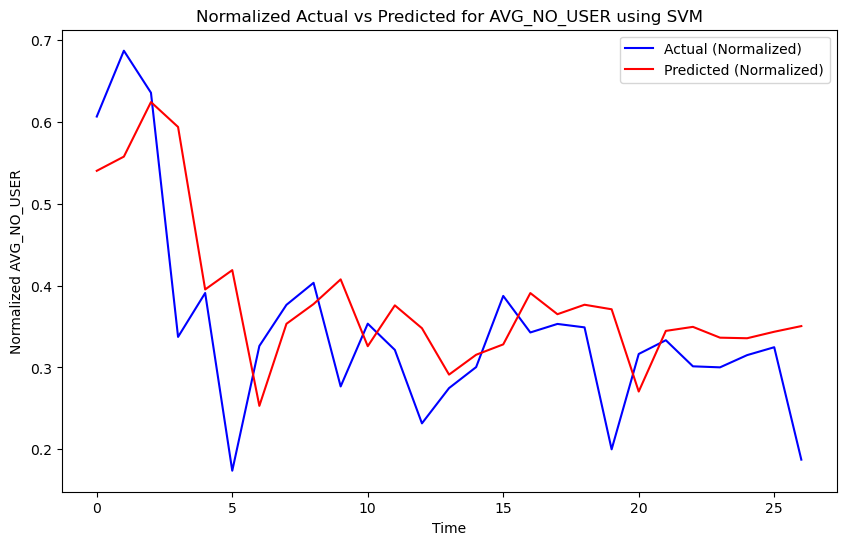

In [4]:


# Function to create dataset matrix for SVM
def create_dataset_svm(dataset, look_back=1):
    X, Y = [], []
    for i in range(len(dataset) - look_back):
        X.append(dataset[i:(i + look_back), 0])  # Flatten to a 1D array for SVM
        Y.append(dataset[i + look_back, 0])
    return np.array(X), np.array(Y)

# Preparing data for 'Avg_Usr'
feature = 'AVG_NO_USER'

# Normalize the 'Avg_Usr' data
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data[[feature]])

# Split the data into training and test sets (80% train, 20% test)
train_size = int(len(scaled_data) * 0.8)
train, test = scaled_data[:train_size], scaled_data[train_size:]

# Create dataset for SVM (look_back=3)
look_back = 3
X_train, y_train = create_dataset_svm(train, look_back=look_back)
X_test, y_test = create_dataset_svm(test, look_back=look_back)

# Train SVM model with different hyperparameters
best_mse = float('inf')
best_params = {}
best_model = None

# Hyperparameter tuning loop for SVM
for kernel in ['linear', 'rbf', 'poly']:
    for C in [0.1, 1, 10]:
        for gamma in ['scale', 'auto']:
            print(f'Training with kernel={kernel}, C={C}, gamma={gamma}')
            svm_model = SVR(kernel=kernel, C=C, gamma=gamma)
            svm_model.fit(X_train, y_train)
            
            # Predict and calculate MSE
            test_predict = svm_model.predict(X_test)
            mse = mean_squared_error(y_test, test_predict)
            print(f'MSE (normalized): {mse}')
            
            # Track the best model
            if mse < best_mse:
                best_mse = mse
                best_params = {'kernel': kernel, 'C': C, 'gamma': gamma}
                best_model = svm_model

print(f'Best MSE (normalized): {best_mse} with params: {best_params}')

# Predict with the best model
best_test_predict = best_model.predict(X_test)

# Plot the best model's predictions with actual values
plt.figure(figsize=(10, 6))
plt.plot(y_test, label='Actual (Normalized)', color='blue')
plt.plot(best_test_predict, label='Predicted (Normalized)', color='red')
plt.title(f'Normalized Actual vs Predicted for {feature} using SVM')
plt.xlabel('Time')
plt.ylabel(f'Normalized {feature}')
plt.legend()
plt.show()

Training with kernel=linear, C=0.1, gamma=scale
MSE (normalized): 0.0968881289484312
Training with kernel=linear, C=0.1, gamma=auto
MSE (normalized): 0.0968881289484312
Training with kernel=linear, C=1, gamma=scale
MSE (normalized): 0.07386900496160519
Training with kernel=linear, C=1, gamma=auto
MSE (normalized): 0.07386900496160519
Training with kernel=linear, C=10, gamma=scale
MSE (normalized): 0.06104276919807163
Training with kernel=linear, C=10, gamma=auto
MSE (normalized): 0.06104276919807163
Training with kernel=rbf, C=0.1, gamma=scale
MSE (normalized): 0.1616488618608255
Training with kernel=rbf, C=0.1, gamma=auto
MSE (normalized): 0.1222998678377322
Training with kernel=rbf, C=1, gamma=scale
MSE (normalized): 0.15539826784775568
Training with kernel=rbf, C=1, gamma=auto
MSE (normalized): 0.09245795849780604
Training with kernel=rbf, C=10, gamma=scale
MSE (normalized): 0.13889185887252295
Training with kernel=rbf, C=10, gamma=auto
MSE (normalized): 0.04593171312835888
Training

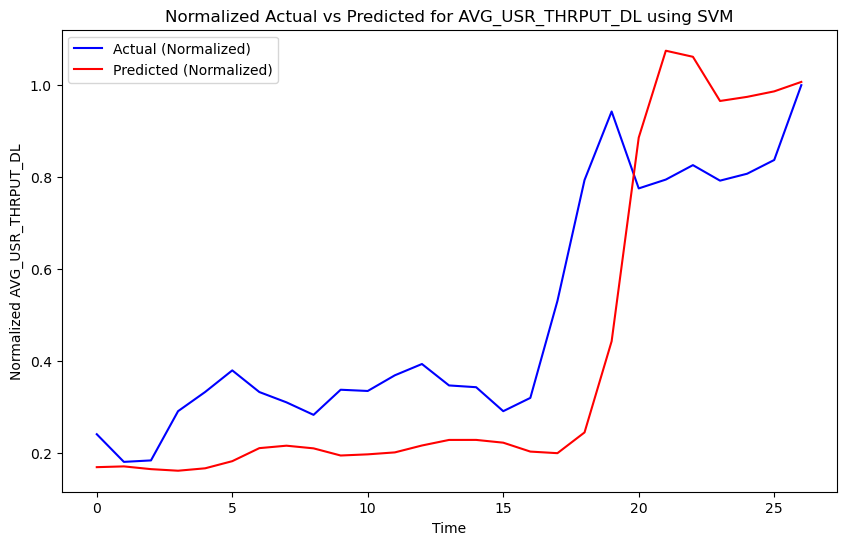

In [5]:


# Function to create dataset matrix for SVM
def create_dataset_svm(dataset, look_back=1):
    X, Y = [], []
    for i in range(len(dataset) - look_back):
        X.append(dataset[i:(i + look_back), 0])  # Flatten to a 1D array for SVM
        Y.append(dataset[i + look_back, 0])
    return np.array(X), np.array(Y)

# Preparing data for 'Avg_Usr'
feature = 'AVG_USR_THRPUT_DL'

# Normalize the 'Avg_Usr' data
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data[[feature]])

# Split the data into training and test sets (80% train, 20% test)
train_size = int(len(scaled_data) * 0.8)
train, test = scaled_data[:train_size], scaled_data[train_size:]

# Create dataset for SVM (look_back=3)
look_back = 3
X_train, y_train = create_dataset_svm(train, look_back=look_back)
X_test, y_test = create_dataset_svm(test, look_back=look_back)

# Train SVM model with different hyperparameters
best_mse = float('inf')
best_params = {}
best_model = None

# Hyperparameter tuning loop for SVM
for kernel in ['linear', 'rbf', 'poly']:
    for C in [0.1, 1, 10]:
        for gamma in ['scale', 'auto']:
            print(f'Training with kernel={kernel}, C={C}, gamma={gamma}')
            svm_model = SVR(kernel=kernel, C=C, gamma=gamma)
            svm_model.fit(X_train, y_train)
            
            # Predict and calculate MSE
            test_predict = svm_model.predict(X_test)
            mse = mean_squared_error(y_test, test_predict)
            print(f'MSE (normalized): {mse}')
            
            # Track the best model
            if mse < best_mse:
                best_mse = mse
                best_params = {'kernel': kernel, 'C': C, 'gamma': gamma}
                best_model = svm_model

print(f'Best MSE (normalized): {best_mse} with params: {best_params}')

# Predict with the best model
best_test_predict = best_model.predict(X_test)

# Plot the best model's predictions with actual values
plt.figure(figsize=(10, 6))
plt.plot(y_test, label='Actual (Normalized)', color='blue')
plt.plot(best_test_predict, label='Predicted (Normalized)', color='red')
plt.title(f'Normalized Actual vs Predicted for {feature} using SVM')
plt.xlabel('Time')
plt.ylabel(f'Normalized {feature}')
plt.legend()
plt.show()

Training with kernel=linear, C=0.1, gamma=scale
MSE (normalized): 0.005389639559058809
Training with kernel=linear, C=0.1, gamma=auto
MSE (normalized): 0.005389639559058809
Training with kernel=linear, C=1, gamma=scale
MSE (normalized): 0.0023854813676073847
Training with kernel=linear, C=1, gamma=auto
MSE (normalized): 0.0023854813676073847
Training with kernel=linear, C=10, gamma=scale
MSE (normalized): 0.001930406894993035
Training with kernel=linear, C=10, gamma=auto
MSE (normalized): 0.001930406894993035
Training with kernel=rbf, C=0.1, gamma=scale
MSE (normalized): 0.005281819054316523
Training with kernel=rbf, C=0.1, gamma=auto
MSE (normalized): 0.006119617641468619
Training with kernel=rbf, C=1, gamma=scale
MSE (normalized): 0.004935512019266467
Training with kernel=rbf, C=1, gamma=auto
MSE (normalized): 0.0022749065584402105
Training with kernel=rbf, C=10, gamma=scale
MSE (normalized): 0.0029113844595639463
Training with kernel=rbf, C=10, gamma=auto
MSE (normalized): 0.0013392

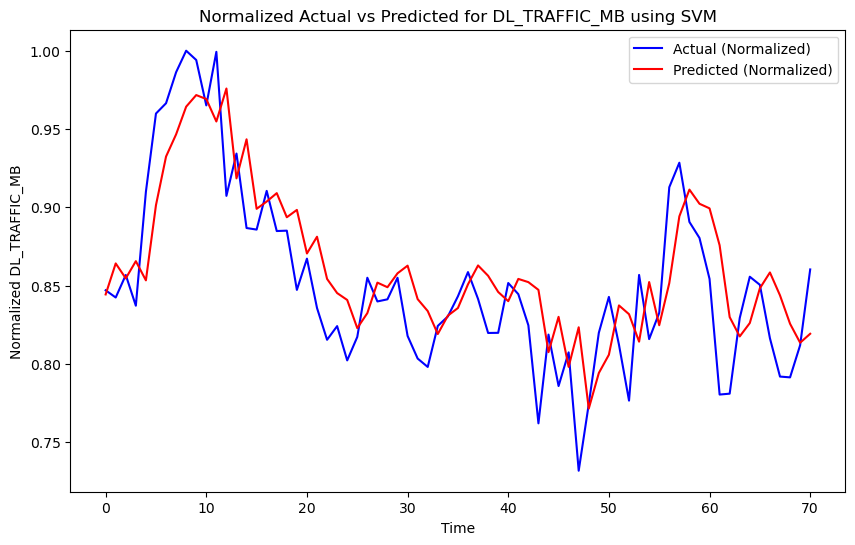

In [33]:
# Load your dataset (adjust the path to where your file is located)
data = pd.read_csv('../../data/Site3data.csv')

# Function to create dataset matrix for SVM
def create_dataset_svm(dataset, look_back=1):
    X, Y = [], []
    for i in range(len(dataset) - look_back):
        X.append(dataset[i:(i + look_back), 0])  # Flatten to a 1D array for SVM
        Y.append(dataset[i + look_back, 0])
    return np.array(X), np.array(Y)

# Preparing data for 'Avg_Usr'
feature = 'DL_TRAFFIC_MB'

# Normalize the 'Avg_Usr' data
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data[[feature]])

# Split the data into training and test sets (80% train, 20% test)
train_size = int(len(scaled_data) * 0.8)
train, test = scaled_data[:train_size], scaled_data[train_size:]

# Create dataset for SVM (look_back=3)
look_back = 3
X_train, y_train = create_dataset_svm(train, look_back=look_back)
X_test, y_test = create_dataset_svm(test, look_back=look_back)

# Train SVM model with different hyperparameters
best_mse = float('inf')
best_params = {}
best_model = None

# Hyperparameter tuning loop for SVM
for kernel in ['linear', 'rbf', 'poly']:
    for C in [0.1, 1, 10]:
        for gamma in ['scale', 'auto']:
            print(f'Training with kernel={kernel}, C={C}, gamma={gamma}')
            svm_model = SVR(kernel=kernel, C=C, gamma=gamma)
            svm_model.fit(X_train, y_train)
            
            # Predict and calculate MSE
            test_predict = svm_model.predict(X_test)
            mse = mean_squared_error(y_test, test_predict)
            print(f'MSE (normalized): {mse}')
            
            # Track the best model
            if mse < best_mse:
                best_mse = mse
                best_params = {'kernel': kernel, 'C': C, 'gamma': gamma}
                best_model = svm_model

print(f'Best MSE (normalized): {best_mse} with params: {best_params}')

# Predict with the best model
best_test_predict = best_model.predict(X_test)

# Plot the best model's predictions with actual values
plt.figure(figsize=(10, 6))
plt.plot(y_test, label='Actual (Normalized)', color='blue')
plt.plot(best_test_predict, label='Predicted (Normalized)', color='red')
plt.title(f'Normalized Actual vs Predicted for {feature} using SVM')
plt.xlabel('Time')
plt.ylabel(f'Normalized {feature}')
plt.legend()
plt.show()

In [7]:
# Function to create dataset matrix for GRU
def create_dataset_gru(dataset, look_back=1):
    X, Y = [], []
    for i in range(len(dataset) - look_back):
        X.append(dataset[i:(i + look_back), 0])
        Y.append(dataset[i + look_back, 0])
    return np.array(X), np.array(Y)

# Preparing data for 'AVG_NO_USER'
feature = 'AVG_NO_USER'
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data[[feature]])

# Split the data into training and test sets (80% train, 20% test)
train_size = int(len(scaled_data) * 0.8)
train, test = scaled_data[:train_size], scaled_data[train_size:]


In [8]:
from sklearn.svm import SVR
from sklearn.preprocessing import MaxAbsScaler

from statsmodels.tsa.arima.model import ARIMA
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.layers import Dense, GRU, Dropout



Epoch 1/50
4/4 [==============================] - 15s 695ms/step - loss: 0.1935 - val_loss: 0.0645
Epoch 2/50
4/4 [==============================] - 0s 31ms/step - loss: 0.0601 - val_loss: 0.0182
Epoch 3/50
4/4 [==============================] - 0s 24ms/step - loss: 0.0656 - val_loss: 0.0357
Epoch 4/50
4/4 [==============================] - 0s 22ms/step - loss: 0.0670 - val_loss: 0.0166
Epoch 5/50
4/4 [==============================] - 0s 22ms/step - loss: 0.0460 - val_loss: 0.0196
Epoch 6/50
4/4 [==============================] - 0s 24ms/step - loss: 0.0471 - val_loss: 0.0327
Epoch 7/50
4/4 [==============================] - 0s 25ms/step - loss: 0.0530 - val_loss: 0.0302
Epoch 8/50
4/4 [==============================] - 0s 26ms/step - loss: 0.0499 - val_loss: 0.0182
Epoch 9/50
4/4 [==============================] - 0s 23ms/step - loss: 0.0448 - val_loss: 0.0144
Epoch 10/50
4/4 [==============================] - 0s 19ms/step - loss: 0.0443 - val_loss: 0.0147
Epoch 11/50
4/4 [==========

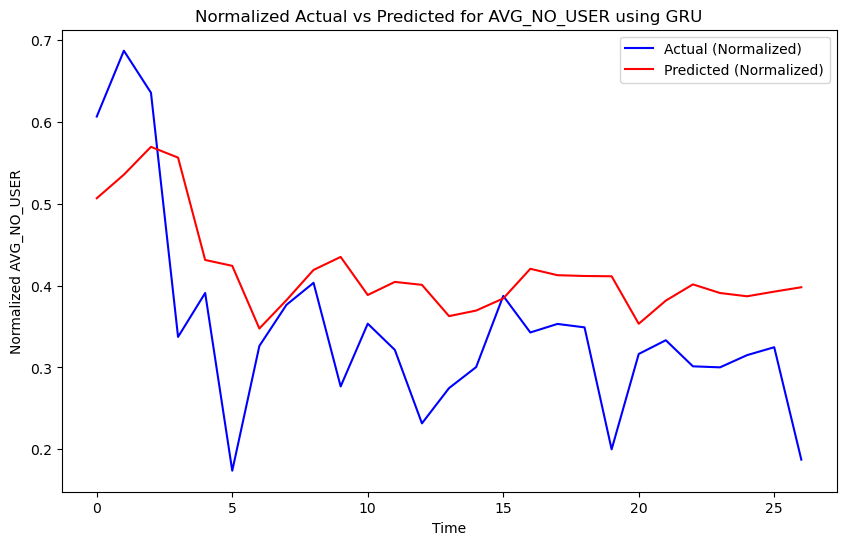

In [9]:
# Create dataset for GRU (look_back=3)
look_back = 3
X_train, y_train = create_dataset_gru(train, look_back=look_back)
X_test, y_test = create_dataset_gru(test, look_back=look_back)
# Reshape input to be [samples, timesteps, features] for GRU
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

# Define the GRU model
def build_gru_model(input_shape):
    model = Sequential()
    model.add(GRU(100, return_sequences=True, input_shape=input_shape))
    model.add(Dropout(0.2))
    model.add(GRU(50, return_sequences=False))
    model.add(Dense(1))  # Output layer for regression
    
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

# Build and train GRU model
gru_model = build_gru_model((look_back, 1))
gru_model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

# Predict with the GRU model
train_predict_gru = gru_model.predict(X_train)
test_predict_gru = gru_model.predict(X_test)

# Calculate MSE for the GRU model
gru_mse = mean_squared_error(y_test, test_predict_gru)
print(f'GRU Model MSE (Normalized): {gru_mse}')

# Plot the GRU model's predictions with actual values
plt.figure(figsize=(10, 6))
plt.plot(y_test, label='Actual (Normalized)', color='blue')
plt.plot(test_predict_gru, label='Predicted (Normalized)', color='red')
plt.title(f'Normalized Actual vs Predicted for {feature} using GRU')
plt.xlabel('Time')
plt.ylabel(f'Normalized {feature}')
plt.legend()
plt.show()

Epoch 1/50
4/4 [==============================] - 12s 572ms/step - loss: 0.0282 - val_loss: 0.0027
Epoch 2/50
4/4 [==============================] - 0s 18ms/step - loss: 0.0057 - val_loss: 0.0052
Epoch 3/50
4/4 [==============================] - 0s 19ms/step - loss: 0.0091 - val_loss: 0.0033
Epoch 4/50
4/4 [==============================] - 0s 20ms/step - loss: 0.0053 - val_loss: 5.7439e-04
Epoch 5/50
4/4 [==============================] - 0s 18ms/step - loss: 0.0047 - val_loss: 0.0021
Epoch 6/50
4/4 [==============================] - 0s 20ms/step - loss: 0.0056 - val_loss: 0.0016
Epoch 7/50
4/4 [==============================] - 0s 20ms/step - loss: 0.0050 - val_loss: 6.3579e-04
Epoch 8/50
4/4 [==============================] - 0s 20ms/step - loss: 0.0042 - val_loss: 7.9831e-04
Epoch 9/50
4/4 [==============================] - 0s 18ms/step - loss: 0.0044 - val_loss: 9.0209e-04
Epoch 10/50
4/4 [==============================] - 0s 43ms/step - loss: 0.0041 - val_loss: 6.0243e-04
Epoch 1

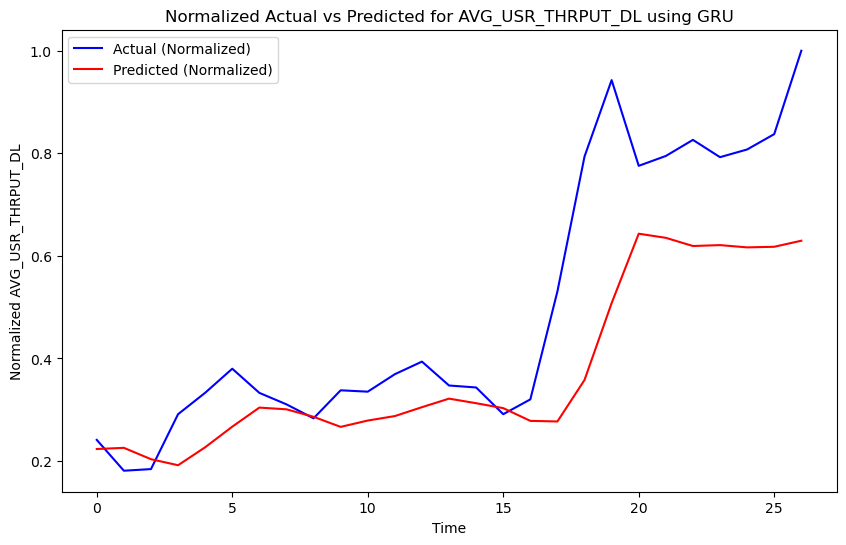

In [10]:
# Function to create dataset matrix for GRU
def create_dataset_gru(dataset, look_back=1):
    X, Y = [], []
    for i in range(len(dataset) - look_back):
        X.append(dataset[i:(i + look_back), 0])
        Y.append(dataset[i + look_back, 0])
    return np.array(X), np.array(Y)

# Preparing data for 'AVG_NO_USER'
feature = 'AVG_USR_THRPUT_DL'
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data[[feature]])

# Split the data into training and test sets (80% train, 20% test)
train_size = int(len(scaled_data) * 0.8)
train, test = scaled_data[:train_size], scaled_data[train_size:]

# Create dataset for GRU (look_back=3)
look_back = 3
X_train, y_train = create_dataset_gru(train, look_back=look_back)
X_test, y_test = create_dataset_gru(test, look_back=look_back)

# Reshape input to be [samples, timesteps, features] for GRU
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

# Define the GRU model
def build_gru_model(input_shape):
    model = Sequential()
    model.add(GRU(100, return_sequences=True, input_shape=input_shape))
    model.add(Dropout(0.2))
    model.add(GRU(50, return_sequences=False))
    model.add(Dense(1))  # Output layer for regression
    
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

# Build and train GRU model
gru_model = build_gru_model((look_back, 1))
gru_model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

# Predict with the GRU model
train_predict_gru = gru_model.predict(X_train)
test_predict_gru = gru_model.predict(X_test)

# Calculate MSE for the GRU model
gru_mse = mean_squared_error(y_test, test_predict_gru)
print(f'GRU Model MSE (Normalized): {gru_mse}')

# Plot the GRU model's predictions with actual values
plt.figure(figsize=(10, 6))
plt.plot(y_test, label='Actual (Normalized)', color='blue')
plt.plot(test_predict_gru, label='Predicted (Normalized)', color='red')
plt.title(f'Normalized Actual vs Predicted for {feature} using GRU')
plt.xlabel('Time')
plt.ylabel(f'Normalized {feature}')
plt.legend()
plt.show()

Epoch 1/50
9/9 [==============================] - 9s 135ms/step - loss: 0.1464 - val_loss: 0.0043
Epoch 2/50
9/9 [==============================] - 0s 12ms/step - loss: 0.0324 - val_loss: 0.0013
Epoch 3/50
9/9 [==============================] - 0s 13ms/step - loss: 0.0092 - val_loss: 0.0172
Epoch 4/50
9/9 [==============================] - 0s 11ms/step - loss: 0.0102 - val_loss: 7.7098e-04
Epoch 5/50
9/9 [==============================] - 0s 13ms/step - loss: 0.0080 - val_loss: 6.3364e-04
Epoch 6/50
9/9 [==============================] - 0s 12ms/step - loss: 0.0067 - val_loss: 0.0043
Epoch 7/50
9/9 [==============================] - 0s 13ms/step - loss: 0.0066 - val_loss: 7.5683e-04
Epoch 8/50
9/9 [==============================] - 0s 14ms/step - loss: 0.0070 - val_loss: 8.3100e-04
Epoch 9/50
9/9 [==============================] - 0s 13ms/step - loss: 0.0059 - val_loss: 0.0028
Epoch 10/50
9/9 [==============================] - 0s 12ms/step - loss: 0.0060 - val_loss: 7.8829e-04
Epoch 11

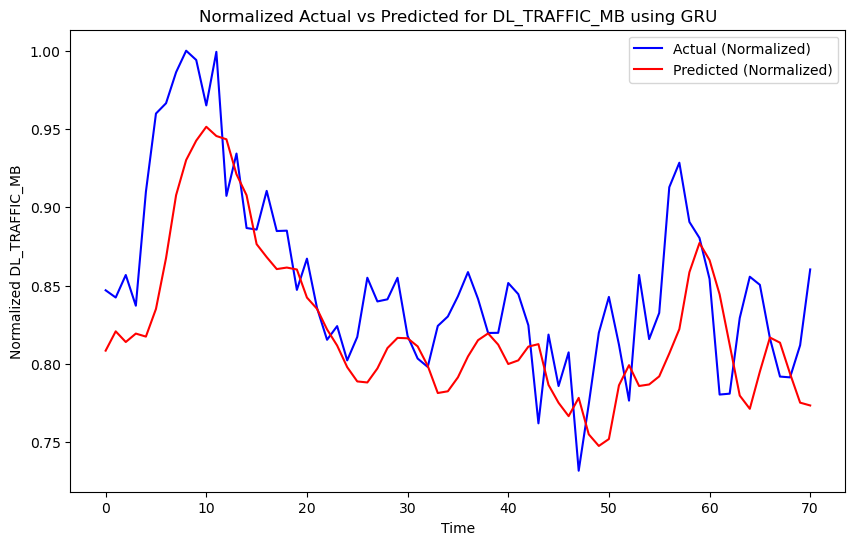

In [34]:
# Load your dataset (adjust the path to where your file is located)
data = pd.read_csv('../../data/Site3data.csv')

# Function to create dataset matrix for GRU
def create_dataset_gru(dataset, look_back=1):
    X, Y = [], []
    for i in range(len(dataset) - look_back):
        X.append(dataset[i:(i + look_back), 0])
        Y.append(dataset[i + look_back, 0])
    return np.array(X), np.array(Y)

# Preparing data for 'AVG_NO_USER'
feature = 'DL_TRAFFIC_MB'
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data[[feature]])

# Split the data into training and test sets (80% train, 20% test)
train_size = int(len(scaled_data) * 0.8)
train, test = scaled_data[:train_size], scaled_data[train_size:]

# Create dataset for GRU (look_back=3)
look_back = 3
X_train, y_train = create_dataset_gru(train, look_back=look_back)
X_test, y_test = create_dataset_gru(test, look_back=look_back)

# Reshape input to be [samples, timesteps, features] for GRU
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

# Define the GRU model
def build_gru_model(input_shape):
    model = Sequential()
    model.add(GRU(100, return_sequences=True, input_shape=input_shape))
    model.add(Dropout(0.2))
    model.add(GRU(50, return_sequences=False))
    model.add(Dense(1))  # Output layer for regression
    
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

# Build and train GRU model
gru_model = build_gru_model((look_back, 1))
gru_model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

# Predict with the GRU model
train_predict_gru = gru_model.predict(X_train)
test_predict_gru = gru_model.predict(X_test)

# Calculate MSE for the GRU model
gru_mse = mean_squared_error(y_test, test_predict_gru)
print(f'GRU Model MSE (Normalized): {gru_mse}')

# Plot the GRU model's predictions with actual values
plt.figure(figsize=(10, 6))
plt.plot(y_test, label='Actual (Normalized)', color='blue')
plt.plot(test_predict_gru, label='Predicted (Normalized)', color='red')
plt.title(f'Normalized Actual vs Predicted for {feature} using GRU')
plt.xlabel('Time')
plt.ylabel(f'Normalized {feature}')
plt.legend()
plt.show()

Epoch 1/50
4/4 [==============================] - 13s 839ms/step - loss: 0.2757 - val_loss: 0.2302
Epoch 2/50
4/4 [==============================] - 0s 22ms/step - loss: 0.2037 - val_loss: 0.1522
Epoch 3/50
4/4 [==============================] - 0s 42ms/step - loss: 0.1350 - val_loss: 0.0783
Epoch 4/50
4/4 [==============================] - 0s 22ms/step - loss: 0.0803 - val_loss: 0.0248
Epoch 5/50
4/4 [==============================] - 0s 22ms/step - loss: 0.0511 - val_loss: 0.0177
Epoch 6/50
4/4 [==============================] - 0s 21ms/step - loss: 0.0605 - val_loss: 0.0220
Epoch 7/50
4/4 [==============================] - 0s 19ms/step - loss: 0.0599 - val_loss: 0.0150
Epoch 8/50
4/4 [==============================] - 0s 21ms/step - loss: 0.0508 - val_loss: 0.0189
Epoch 9/50
4/4 [==============================] - 0s 21ms/step - loss: 0.0489 - val_loss: 0.0259
Epoch 10/50
4/4 [==============================] - 0s 30ms/step - loss: 0.0513 - val_loss: 0.0266
Epoch 11/50
4/4 [==========

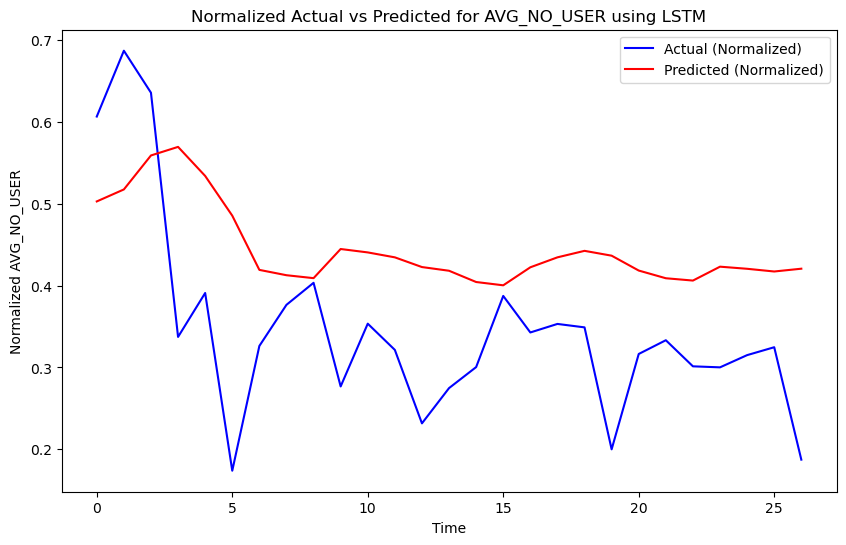

In [12]:
# Function to create dataset matrix for LSTM
def create_dataset_lstm(dataset, look_back=1):
    X, Y = [], []
    for i in range(len(dataset) - look_back):
        X.append(dataset[i:(i + look_back), 0])
        Y.append(dataset[i + look_back, 0])
    return np.array(X), np.array(Y)

# Preparing data for 'AVG_NO_USER'
feature = 'AVG_NO_USER'
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data[[feature]])

# Split the data into training and test sets (80% train, 20% test)
train_size = int(len(scaled_data) * 0.8)
train, test = scaled_data[:train_size], scaled_data[train_size:]

# Create dataset for LSTM (look_back=3)
look_back = 3
X_train, y_train = create_dataset_lstm(train, look_back=look_back)
X_test, y_test = create_dataset_lstm(test, look_back=look_back)

# Reshape input to be [samples, timesteps, features] for LSTM
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

# Define the LSTM model
def build_lstm_model(input_shape):
    model = Sequential()
    model.add(LSTM(100, return_sequences=True, input_shape=input_shape))
    model.add(Dropout(0.2))
    model.add(LSTM(50, return_sequences=False))
    model.add(Dense(1))  # Output layer for regression
    
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

# Build and train LSTM model
lstm_model = build_lstm_model((look_back, 1))
lstm_model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

# Predict with the LSTM model
train_predict_lstm = lstm_model.predict(X_train)
test_predict_lstm = lstm_model.predict(X_test)

# Calculate MSE for the LSTM model
lstm_mse = mean_squared_error(y_test, test_predict_lstm)
print(f'LSTM Model MSE (Normalized): {lstm_mse}')

# Plot the LSTM model's predictions with actual values
plt.figure(figsize=(10, 6))
plt.plot(y_test, label='Actual (Normalized)', color='blue')
plt.plot(test_predict_lstm, label='Predicted (Normalized)', color='red')
plt.title(f'Normalized Actual vs Predicted for {feature} using LSTM')
plt.xlabel('Time')
plt.ylabel(f'Normalized {feature}')
plt.legend()
plt.show()

Epoch 1/50
9/9 [==============================] - 8s 224ms/step - loss: 0.0380 - val_loss: 0.0194
Epoch 2/50
9/9 [==============================] - 0s 13ms/step - loss: 0.0135 - val_loss: 6.9943e-04
Epoch 3/50
9/9 [==============================] - 0s 17ms/step - loss: 0.0109 - val_loss: 7.2937e-04
Epoch 4/50
9/9 [==============================] - 0s 13ms/step - loss: 0.0084 - val_loss: 0.0029
Epoch 5/50
9/9 [==============================] - 0s 15ms/step - loss: 0.0079 - val_loss: 0.0014
Epoch 6/50
9/9 [==============================] - 0s 16ms/step - loss: 0.0062 - val_loss: 7.1336e-04
Epoch 7/50
9/9 [==============================] - 0s 14ms/step - loss: 0.0056 - val_loss: 8.1734e-04
Epoch 8/50
9/9 [==============================] - 0s 16ms/step - loss: 0.0049 - val_loss: 9.3079e-04
Epoch 9/50
9/9 [==============================] - 0s 14ms/step - loss: 0.0050 - val_loss: 8.9862e-04
Epoch 10/50
9/9 [==============================] - 0s 17ms/step - loss: 0.0049 - val_loss: 9.2848e-04


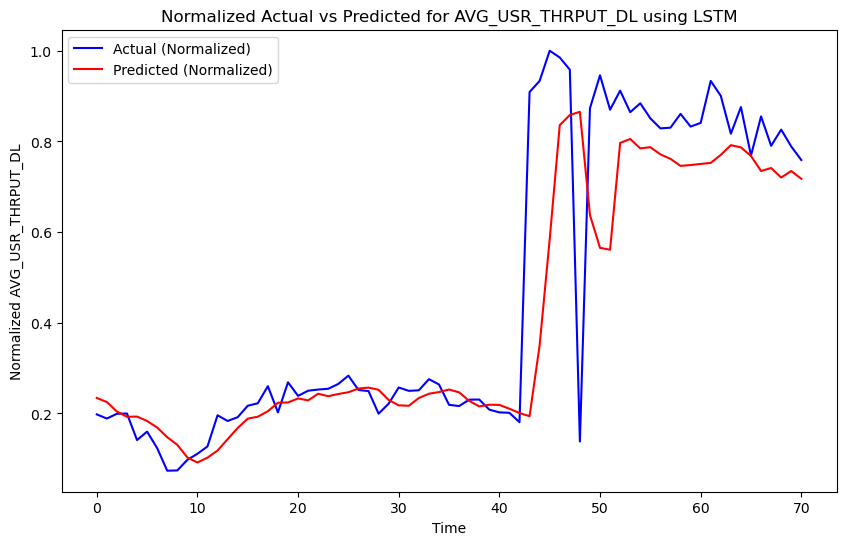

In [35]:
# Load your dataset (adjust the path to where your file is located)
data = pd.read_csv('../../data/Site3data.csv')

# Function to create dataset matrix for LSTM
def create_dataset_lstm(dataset, look_back=1):
    X, Y = [], []
    for i in range(len(dataset) - look_back):
        X.append(dataset[i:(i + look_back), 0])
        Y.append(dataset[i + look_back, 0])
    return np.array(X), np.array(Y)

# Preparing data for 'AVG_NO_USER'
feature = 'AVG_USR_THRPUT_DL'
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data[[feature]])

# Split the data into training and test sets (80% train, 20% test)
train_size = int(len(scaled_data) * 0.8)
train, test = scaled_data[:train_size], scaled_data[train_size:]

# Create dataset for LSTM (look_back=3)
look_back = 3
X_train, y_train = create_dataset_lstm(train, look_back=look_back)
X_test, y_test = create_dataset_lstm(test, look_back=look_back)

# Reshape input to be [samples, timesteps, features] for LSTM
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

# Define the LSTM model
def build_lstm_model(input_shape):
    model = Sequential()
    model.add(LSTM(100, return_sequences=True, input_shape=input_shape))
    model.add(Dropout(0.2))
    model.add(LSTM(50, return_sequences=False))
    model.add(Dense(1))  # Output layer for regression
    
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

# Build and train LSTM model
lstm_model = build_lstm_model((look_back, 1))
lstm_model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

# Predict with the LSTM model
train_predict_lstm = lstm_model.predict(X_train)
test_predict_lstm = lstm_model.predict(X_test)

# Calculate MSE for the LSTM model
lstm_mse = mean_squared_error(y_test, test_predict_lstm)
print(f'LSTM Model MSE (Normalized): {lstm_mse}')

# Plot the LSTM model's predictions with actual values
plt.figure(figsize=(10, 6))
plt.plot(y_test, label='Actual (Normalized)', color='blue')
plt.plot(test_predict_lstm, label='Predicted (Normalized)', color='red')
plt.title(f'Normalized Actual vs Predicted for {feature} using LSTM')
plt.xlabel('Time')
plt.ylabel(f'Normalized {feature}')
plt.legend()
plt.show()

Epoch 1/50
9/9 [==============================] - 10s 190ms/step - loss: 0.3297 - val_loss: 0.1589
Epoch 2/50
9/9 [==============================] - 0s 11ms/step - loss: 0.0441 - val_loss: 0.0475
Epoch 3/50
9/9 [==============================] - 0s 11ms/step - loss: 0.0237 - val_loss: 0.0191
Epoch 4/50
9/9 [==============================] - 0s 11ms/step - loss: 0.0167 - val_loss: 0.0087
Epoch 5/50
9/9 [==============================] - 0s 11ms/step - loss: 0.0084 - val_loss: 0.0011
Epoch 6/50
9/9 [==============================] - 0s 11ms/step - loss: 0.0080 - val_loss: 0.0047
Epoch 7/50
9/9 [==============================] - 0s 11ms/step - loss: 0.0072 - val_loss: 0.0013
Epoch 8/50
9/9 [==============================] - 0s 11ms/step - loss: 0.0064 - val_loss: 0.0018
Epoch 9/50
9/9 [==============================] - 0s 12ms/step - loss: 0.0067 - val_loss: 0.0022
Epoch 10/50
9/9 [==============================] - 0s 11ms/step - loss: 0.0068 - val_loss: 0.0015
Epoch 11/50
9/9 [==========

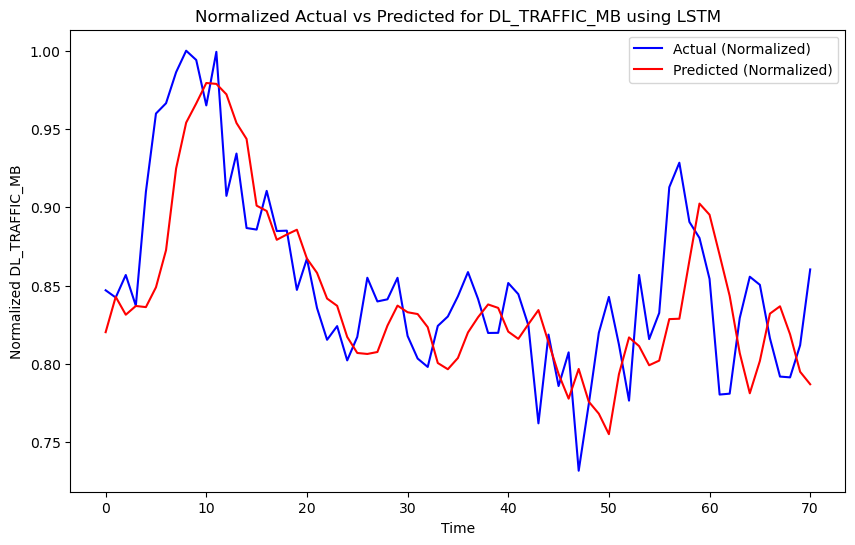

In [36]:
# Load your dataset (adjust the path to where your file is located)
data = pd.read_csv('../../data/Site3data.csv')

# Function to create dataset matrix for LSTM
def create_dataset_lstm(dataset, look_back=1):
    X, Y = [], []
    for i in range(len(dataset) - look_back):
        X.append(dataset[i:(i + look_back), 0])
        Y.append(dataset[i + look_back, 0])
    return np.array(X), np.array(Y)

# Preparing data for 'AVG_NO_USER'
feature = 'DL_TRAFFIC_MB'
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data[[feature]])

# Split the data into training and test sets (80% train, 20% test)
train_size = int(len(scaled_data) * 0.8)
train, test = scaled_data[:train_size], scaled_data[train_size:]

# Create dataset for LSTM (look_back=3)
look_back = 3
X_train, y_train = create_dataset_lstm(train, look_back=look_back)
X_test, y_test = create_dataset_lstm(test, look_back=look_back)

# Reshape input to be [samples, timesteps, features] for LSTM
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

# Define the LSTM model
def build_lstm_model(input_shape):
    model = Sequential()
    model.add(LSTM(150, return_sequences=True, input_shape=input_shape))
    model.add(Dropout(0.3))
    model.add(LSTM(100, return_sequences=False))
    model.add(Dense(1))  # Output layer for regression
    
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

# Build and train LSTM model
lstm_model = build_lstm_model((look_back, 1))
lstm_model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

# Predict with the LSTM model
train_predict_lstm = lstm_model.predict(X_train)
test_predict_lstm = lstm_model.predict(X_test)

# Calculate MSE for the LSTM model
lstm_mse = mean_squared_error(y_test, test_predict_lstm)
print(f'LSTM Model MSE (Normalized): {lstm_mse}')

# Plot the LSTM model's predictions with actual values
plt.figure(figsize=(10, 6))
plt.plot(y_test, label='Actual (Normalized)', color='blue')
plt.plot(test_predict_lstm, label='Predicted (Normalized)', color='red')
plt.title(f'Normalized Actual vs Predicted for {feature} using LSTM')
plt.xlabel('Time')
plt.ylabel(f'Normalized {feature}')
plt.legend()
plt.show()

ARIMA Model MSE (Normalized): 0.017762615759599695


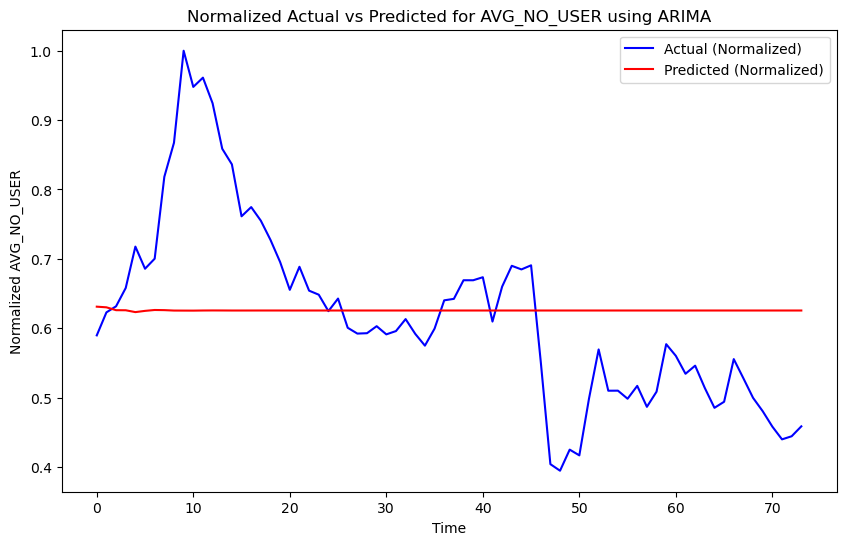

In [15]:
# Load your dataset (adjust the path to where your file is located)
data = pd.read_csv('../../data/Site3data.csv')

# Preparing data for 'AVG_NO_USER'
feature = 'AVG_NO_USER'

# Normalize the 'Avg_Usr' data
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data[[feature]])

# Split the data into training and test sets (80% train, 20% test)
train_size = int(len(scaled_data) * 0.8)
train, test = scaled_data[:train_size], scaled_data[train_size:]

# Flatten the data for ARIMA (since it expects 1D arrays)
train = train.flatten()
test = test.flatten()

# Fit the ARIMA model
# (p, d, q) are ARIMA parameters. Start with simple values like (p=5, d=1, q=0)
model = ARIMA(train, order=(5, 1, 0))  # You can experiment with these values
arima_model = model.fit()

# Make predictions on test data
test_predict_arima = arima_model.forecast(steps=len(test))

# Calculate MSE for ARIMA model
arima_mse = mean_squared_error(test, test_predict_arima)
print(f'ARIMA Model MSE (Normalized): {arima_mse}')

# Plot the ARIMA model's predictions with actual values
plt.figure(figsize=(10, 6))
plt.plot(test, label='Actual (Normalized)', color='blue')
plt.plot(test_predict_arima, label='Predicted (Normalized)', color='red')
plt.title(f'Normalized Actual vs Predicted for {feature} using ARIMA')
plt.xlabel('Time')
plt.ylabel(f'Normalized {feature}')
plt.legend()
plt.show()

In [16]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from statsmodels.tsa.arima.model import ARIMA
from pmdarima import auto_arima
import matplotlib.pyplot as plt

ARIMA Model MSE (Normalized): 0.10958178569562285


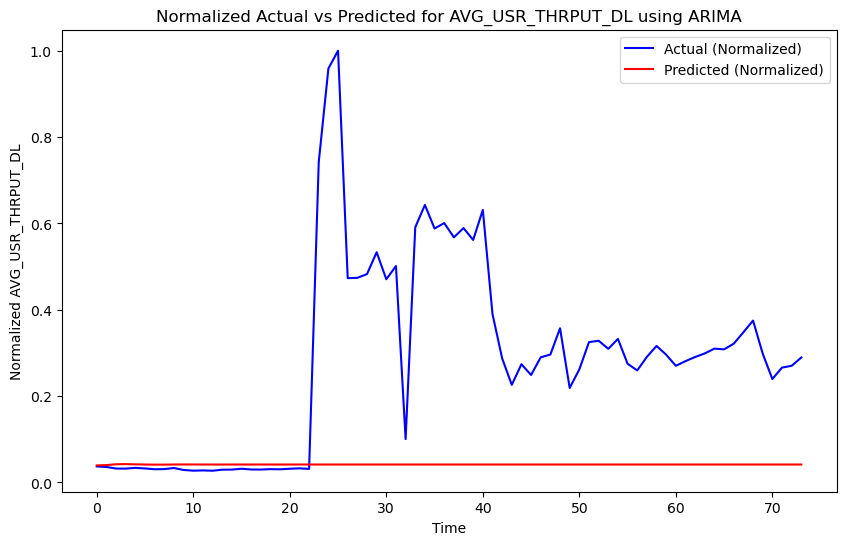

In [72]:
# Load your dataset (adjust the path to where your file is located)
data = pd.read_csv('../../data/Site4data.csv')

# Preparing data for 'AVG_NO_USER'
feature = 'AVG_USR_THRPUT_DL'

# Normalize the 'AVG_USR_THRPUT_DL' data
#scaler = MinMaxScaler(feature_range=(0, 1))
#scaled_data = scaler.fit_transform(data[[feature]])

# Initialize the MaxAbsScaler
scaler = MaxAbsScaler()

# Normalize the 'Traffic' data
scaled_data = scaler.fit_transform(data[[feature]])

# Split the data into training and test sets (80% train, 20% test)
train_size = int(len(scaled_data) * 0.8)
train, test = scaled_data[:train_size], scaled_data[train_size:]

# Flatten the data for ARIMA (since it expects 1D arrays)
train = train.flatten()
test = test.flatten()

# Fit the ARIMA model
# (p, d, q) are ARIMA parameters. Start with simple values like (p=5, d=1, q=0)
model = ARIMA(train, order=(5, 1, 0))  # You can experiment with these values
arima_model = model.fit()

# Make predictions on test data
test_predict_arima = arima_model.forecast(steps=len(test))

# Calculate MSE for ARIMA model
arima_mse = mean_squared_error(test, test_predict_arima)
print(f'ARIMA Model MSE (Normalized): {arima_mse}')

# Plot the ARIMA model's predictions with actual values
plt.figure(figsize=(10, 6))
plt.plot(test, label='Actual (Normalized)', color='blue')
plt.plot(test_predict_arima, label='Predicted (Normalized)', color='red')
plt.title(f'Normalized Actual vs Predicted for {feature} using ARIMA')
plt.xlabel('Time')
plt.ylabel(f'Normalized {feature}')
plt.legend()
plt.show()

ARIMA Model MSE (Normalized): 0.0529473041526384


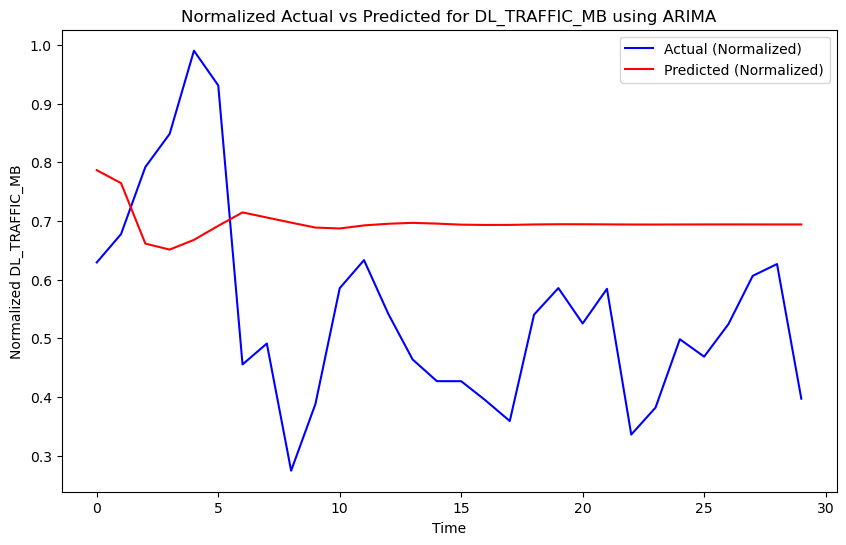

In [59]:
# Load your dataset (adjust the path to where your file is located)
data = pd.read_csv('../../data/Site2data.csv')

# Preparing data for 'AVG_NO_USER'
feature = 'DL_TRAFFIC_MB'

# Normalize the 'Traffic' data
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data[[feature]])

# Initialize the MaxAbsScaler
#scaler = MaxAbsScaler()

# Normalize the 'Traffic' data
#scaled_data = scaler.fit_transform(data[[feature]])

# Split the data into training and test sets (80% train, 20% test)
train_size = int(len(scaled_data) * 0.8)
train, test = scaled_data[:train_size], scaled_data[train_size:]

# Flatten the data for ARIMA (since it expects 1D arrays)
train = train.flatten()
test = test.flatten()

# Fit the ARIMA model
# (p, d, q) are ARIMA parameters. Start with simple values like (p=5, d=1, q=0)
model = ARIMA(train, order=(5, 1, 0))  # You can experiment with these values
arima_model = model.fit()

# Make predictions on test data
test_predict_arima = arima_model.forecast(steps=len(test))

# Calculate MSE for ARIMA model
arima_mse = mean_squared_error(test, test_predict_arima)
print(f'ARIMA Model MSE (Normalized): {arima_mse}')

# Plot the ARIMA model's predictions with actual values
plt.figure(figsize=(10, 6))
plt.plot(test, label='Actual (Normalized)', color='blue')
plt.plot(test_predict_arima, label='Predicted (Normalized)', color='red')
plt.title(f'Normalized Actual vs Predicted for {feature} using ARIMA')
plt.xlabel('Time')
plt.ylabel(f'Normalized {feature}')
plt.legend()
plt.show()

Performing stepwise search to minimize aic
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=-795.803, Time=0.55 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=-701.414, Time=0.12 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=-759.392, Time=0.08 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=-795.494, Time=0.27 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=-703.400, Time=0.08 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=-794.856, Time=0.58 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=-791.609, Time=0.49 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=-795.410, Time=0.42 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=-776.676, Time=0.20 sec
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=1.07 sec
 ARIMA(1,1,1)(0,0,0)[0]             : AIC=-797.506, Time=0.22 sec
 ARIMA(0,1,1)(0,0,0)[0]             : AIC=-797.290, Time=0.13 sec
 ARIMA(1,1,0)(0,0,0)[0]             : AIC=-761.351, Time=0.04 sec
 ARIMA(2,1,1)(0,0,0)[0]             : AIC=-796.486, Time=0.27 sec
 ARIMA(1,1,2)(0,0,0)[0]             : 

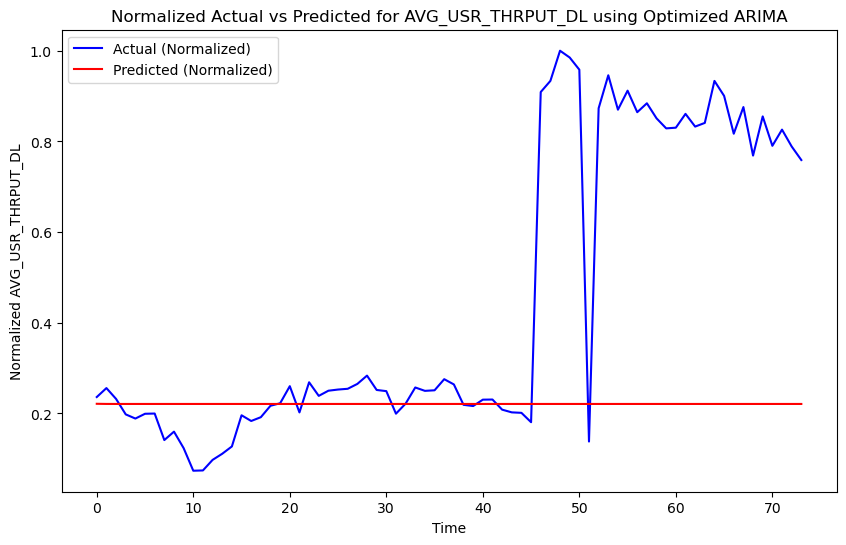

In [19]:
# Load your dataset
data = pd.read_csv('../../data/Site3data.csv')

# Prepare data for 'AVG_NO_USER'
feature = 'AVG_USR_THRPUT_DL'

# Normalize the 'AVG_NO_USER' data
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data[[feature]])

# Split the data into training and test sets (80% train, 20% test)
train_size = int(len(scaled_data) * 0.8)
train, test = scaled_data[:train_size], scaled_data[train_size:]

# Flatten the data for ARIMA (since it expects 1D arrays)
train = train.flatten()
test = test.flatten()

# Find the best ARIMA parameters
stepwise_model = auto_arima(train, start_p=1, start_q=1,
                            max_p=6, max_q=6, m=1,
                            start_P=0, seasonal=False,
                            d=1, trace=True,
                            error_action='ignore',  
                            suppress_warnings=True, 
                            stepwise=True)

# Fit the ARIMA model with the optimal parameters
arima_model = ARIMA(train, order=stepwise_model.order)
arima_model_fit = arima_model.fit()

# Make predictions on test data
test_predict_arima = arima_model_fit.forecast(steps=len(test))

# Calculate MSE for ARIMA model
arima_mse = mean_squared_error(test, test_predict_arima)
print(f'Optimized ARIMA Model MSE (Normalized): {arima_mse}')

# Plot the ARIMA model's predictions with actual values
plt.figure(figsize=(10, 6))
plt.plot(test, label='Actual (Normalized)', color='blue')
plt.plot(test_predict_arima, label='Predicted (Normalized)', color='red')
plt.title(f'Normalized Actual vs Predicted for {feature} using Optimized ARIMA')
plt.xlabel('Time')
plt.ylabel(f'Normalized {feature}')
plt.legend()
plt.show()

In [20]:
data

,Date,AVG_NO_USER,DL_TRAFFIC_MB,AVG_USR_THRPUT_DL
0,2022-09-01 00:00:00,236.47,477293.49,3.246667
1,2022-09-02 00:00:00,246.26,498918.08,3.093333
2,2022-09-03 00:00:00,239.56,486175.40,3.566667
3,2022-09-04 00:00:00,244.27,487563.37,3.066667
4,2022-09-05 00:00:00,237.63,477522.11,3.736667
...,...,...,...,...
361,2023-08-28 00:00:00,273.60,795518.09,15.812222
362,2023-08-29 00:00:00,265.87,773678.51,14.766667
363,2023-08-30 00:00:00,259.48,773228.51,15.342222
364,2023-08-31 00:00:00,261.04,791545.99,14.743333


In [73]:
import numpy as np
import pandas as pd
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout
import matplotlib.pyplot as plt

Epoch 1/50
4/4 [==============================] - 14s 773ms/step - loss: 0.2047 - val_loss: 0.0436
Epoch 2/50
4/4 [==============================] - 0s 38ms/step - loss: 0.0428 - val_loss: 0.0342
Epoch 3/50
4/4 [==============================] - 0s 24ms/step - loss: 0.0556 - val_loss: 0.0522
Epoch 4/50
4/4 [==============================] - 0s 20ms/step - loss: 0.0490 - val_loss: 0.0194
Epoch 5/50
4/4 [==============================] - 0s 24ms/step - loss: 0.0287 - val_loss: 0.0175
Epoch 6/50
4/4 [==============================] - 0s 27ms/step - loss: 0.0338 - val_loss: 0.0233
Epoch 7/50
4/4 [==============================] - 0s 25ms/step - loss: 0.0353 - val_loss: 0.0166
Epoch 8/50
4/4 [==============================] - 0s 22ms/step - loss: 0.0267 - val_loss: 0.0162
Epoch 9/50
4/4 [==============================] - 0s 24ms/step - loss: 0.0281 - val_loss: 0.0231
Epoch 10/50
4/4 [==============================] - 0s 27ms/step - loss: 0.0299 - val_loss: 0.0192
Epoch 11/50
4/4 [==========

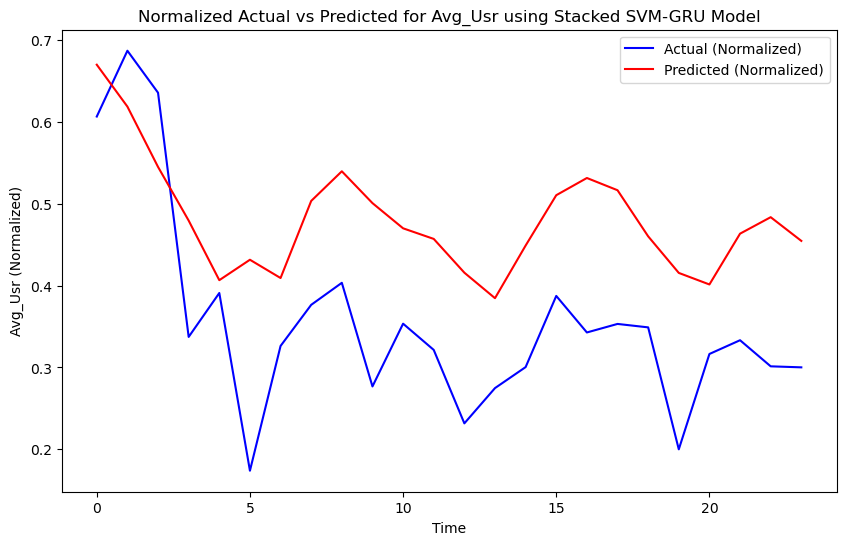

In [22]:

# Load your dataset (adjust the path to where your file is located)
data = pd.read_csv('../../data/Site2data.csv')

# Function to create dataset matrix for SVM
def create_dataset_svm(dataset, look_back=1):
    X, Y = [], []
    for i in range(len(dataset) - look_back):
        X.append(dataset[i:(i + look_back), 0])  # Flatten to 1D array for SVM
        Y.append(dataset[i + look_back, 0])
    return np.array(X), np.array(Y)

# Preparing data for 'AVG_NO_USER'
feature = 'AVG_NO_USER'
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data[[feature]])

# Split the data into training and test sets (80% train, 20% test)
train_size = int(len(scaled_data) * 0.8)
train, test = scaled_data[:train_size], scaled_data[train_size:]

# Create dataset for SVM (look_back=3)
look_back = 3
X_train_svm, y_train_svm = create_dataset_svm(train, look_back=look_back)
X_test_svm, y_test_svm = create_dataset_svm(test, look_back=look_back)

# Train SVM model
svm_model = SVR(kernel='rbf', C=1, gamma='scale')
svm_model.fit(X_train_svm, y_train_svm)

# Predict with SVM model
train_predict_svm = svm_model.predict(X_train_svm)
test_predict_svm = svm_model.predict(X_test_svm)

# Prepare the data for GRU model
def create_dataset_gru(svm_predictions, original_data, look_back=1):
    X, Y = [], []
    for i in range(len(svm_predictions) - look_back):
        # Combine original time series data and SVM predictions as features
        feature_set = np.hstack((original_data[i:(i + look_back)], svm_predictions[i:(i + look_back)].reshape(-1, 1)))
        X.append(feature_set)
        Y.append(original_data[i + look_back, 0])
    return np.array(X), np.array(Y)

# Creating datasets for GRU
X_train_gru, y_train_gru = create_dataset_gru(train_predict_svm, train, look_back=look_back)
X_test_gru, y_test_gru = create_dataset_gru(test_predict_svm, test, look_back=look_back)

# Reshape input data to 3D (samples, timesteps, features) for GRU input
X_train_gru = np.reshape(X_train_gru, (X_train_gru.shape[0], X_train_gru.shape[1], 2))  # Two features: original and SVM
X_test_gru = np.reshape(X_test_gru, (X_test_gru.shape[0], X_test_gru.shape[1], 2))

# Define and train the GRU model
def build_gru_model(input_shape):
    model = Sequential()
    model.add(GRU(100, return_sequences=True, input_shape=input_shape))
    model.add(Dropout(0.2))
    model.add(GRU(50, return_sequences=False))
    model.add(Dense(1))  # Output layer for regression

    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

# Build and train GRU model
gru_model = build_gru_model((look_back, 2))
gru_model.fit(X_train_gru, y_train_gru, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

# Predict with the GRU model
train_predict_gru = gru_model.predict(X_train_gru)
test_predict_gru = gru_model.predict(X_test_gru)

# No need to invert the values; everything stays normalized

# Calculate normalized MSE
normalized_mse = mean_squared_error(y_test_gru, test_predict_gru)
print(f'Normalized MSE: {normalized_mse}')

# Plot the normalized actual vs predicted values
plt.figure(figsize=(10, 6))
plt.plot(y_test_gru, label='Actual (Normalized)', color='blue')
plt.plot(test_predict_gru, label='Predicted (Normalized)', color='red')
plt.title('Normalized Actual vs Predicted for Avg_Usr using Stacked SVM-GRU Model')
plt.xlabel('Time')
plt.ylabel('Avg_Usr (Normalized)')
plt.legend()
plt.show()

Epoch 1/50
9/9 [==============================] - 8s 147ms/step - loss: 0.0286 - val_loss: 0.0102
Epoch 2/50
9/9 [==============================] - 0s 16ms/step - loss: 0.0074 - val_loss: 0.0036
Epoch 3/50
9/9 [==============================] - 0s 17ms/step - loss: 0.0058 - val_loss: 0.0022
Epoch 4/50
9/9 [==============================] - 0s 17ms/step - loss: 0.0031 - val_loss: 0.0018
Epoch 5/50
9/9 [==============================] - 0s 16ms/step - loss: 0.0027 - val_loss: 0.0015
Epoch 6/50
9/9 [==============================] - 0s 17ms/step - loss: 0.0022 - val_loss: 0.0016
Epoch 7/50
9/9 [==============================] - 0s 21ms/step - loss: 0.0019 - val_loss: 0.0015
Epoch 8/50
9/9 [==============================] - 0s 17ms/step - loss: 0.0020 - val_loss: 0.0016
Epoch 9/50
9/9 [==============================] - 0s 32ms/step - loss: 0.0017 - val_loss: 0.0015
Epoch 10/50
9/9 [==============================] - 0s 17ms/step - loss: 0.0017 - val_loss: 0.0018
Epoch 11/50
9/9 [===========

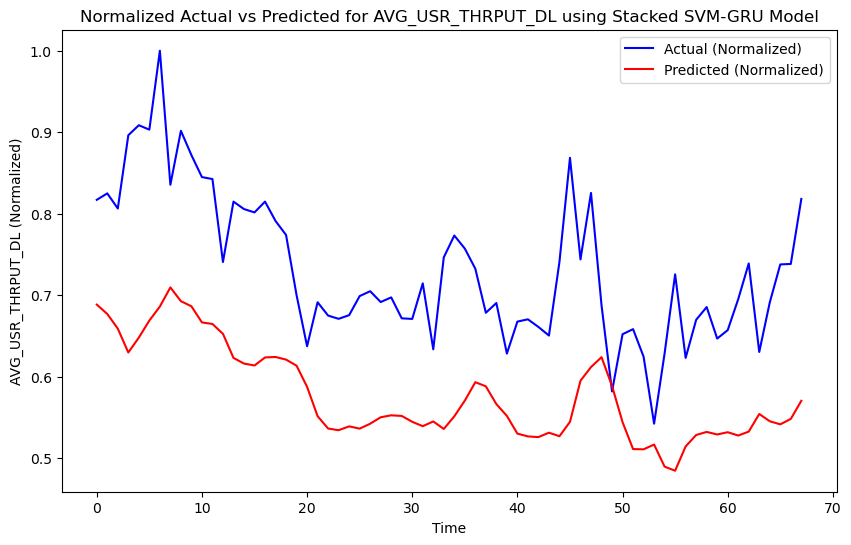

In [40]:

# Load your dataset (adjust the path to where your file is located)
data = pd.read_csv('../../data/Site1data.csv')

# Function to create dataset matrix for SVM
def create_dataset_svm(dataset, look_back=1):
    X, Y = [], []
    for i in range(len(dataset) - look_back):
        X.append(dataset[i:(i + look_back), 0])  # Flatten to 1D array for SVM
        Y.append(dataset[i + look_back, 0])
    return np.array(X), np.array(Y)

# Preparing data for 'AVG_USR_THRPUT_DL'
feature = 'AVG_USR_THRPUT_DL'
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data[[feature]])

# Split the data into training and test sets (80% train, 20% test)
train_size = int(len(scaled_data) * 0.8)
train, test = scaled_data[:train_size], scaled_data[train_size:]

# Create dataset for SVM (look_back=3)
look_back = 3
X_train_svm, y_train_svm = create_dataset_svm(train, look_back=look_back)
X_test_svm, y_test_svm = create_dataset_svm(test, look_back=look_back)

# Train SVM model
svm_model = SVR(kernel='rbf', C=1, gamma='scale')
svm_model.fit(X_train_svm, y_train_svm)

# Predict with SVM model
train_predict_svm = svm_model.predict(X_train_svm)
test_predict_svm = svm_model.predict(X_test_svm)

# Prepare the data for GRU model
def create_dataset_gru(svm_predictions, original_data, look_back=1):
    X, Y = [], []
    for i in range(len(svm_predictions) - look_back):
        # Combine original time series data and SVM predictions as features
        feature_set = np.hstack((original_data[i:(i + look_back)], svm_predictions[i:(i + look_back)].reshape(-1, 1)))
        X.append(feature_set)
        Y.append(original_data[i + look_back, 0])
    return np.array(X), np.array(Y)

# Creating datasets for GRU
X_train_gru, y_train_gru = create_dataset_gru(train_predict_svm, train, look_back=look_back)
X_test_gru, y_test_gru = create_dataset_gru(test_predict_svm, test, look_back=look_back)

# Reshape input data to 3D (samples, timesteps, features) for GRU input
X_train_gru = np.reshape(X_train_gru, (X_train_gru.shape[0], X_train_gru.shape[1], 2))  # Two features: original and SVM
X_test_gru = np.reshape(X_test_gru, (X_test_gru.shape[0], X_test_gru.shape[1], 2))

# Define and train the GRU model
def build_gru_model(input_shape):
    model = Sequential()
    model.add(GRU(100, return_sequences=True, input_shape=input_shape))
    model.add(Dropout(0.2))
    model.add(GRU(50, return_sequences=False))
    model.add(Dense(1))  # Output layer for regression

    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

# Build and train GRU model
gru_model = build_gru_model((look_back, 2))
gru_model.fit(X_train_gru, y_train_gru, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

# Predict with the GRU model
train_predict_gru = gru_model.predict(X_train_gru)
test_predict_gru = gru_model.predict(X_test_gru)

# No need to invert the values; everything stays normalized

# Calculate normalized MSE
normalized_mse = mean_squared_error(y_test_gru, test_predict_gru)
print(f'Normalized MSE: {normalized_mse}')

# Plot the normalized actual vs predicted values
plt.figure(figsize=(10, 6))
plt.plot(y_test_gru, label='Actual (Normalized)', color='blue')
plt.plot(test_predict_gru, label='Predicted (Normalized)', color='red')
plt.title(f'Normalized Actual vs Predicted for {feature} using Stacked SVM-GRU Model')
plt.xlabel('Time')
plt.ylabel(f'{feature} (Normalized)')
plt.legend()
plt.show()

Epoch 1/50
4/4 [==============================] - 8s 390ms/step - loss: 0.2554 - val_loss: 0.0659
Epoch 2/50
4/4 [==============================] - 0s 20ms/step - loss: 0.0584 - val_loss: 0.0319
Epoch 3/50
4/4 [==============================] - 0s 42ms/step - loss: 0.0484 - val_loss: 0.0496
Epoch 4/50
4/4 [==============================] - 0s 30ms/step - loss: 0.0518 - val_loss: 0.0270
Epoch 5/50
4/4 [==============================] - 0s 31ms/step - loss: 0.0317 - val_loss: 0.0194
Epoch 6/50
4/4 [==============================] - 0s 28ms/step - loss: 0.0302 - val_loss: 0.0220
Epoch 7/50
4/4 [==============================] - 0s 32ms/step - loss: 0.0332 - val_loss: 0.0227
Epoch 8/50
4/4 [==============================] - 0s 29ms/step - loss: 0.0319 - val_loss: 0.0195
Epoch 9/50
4/4 [==============================] - 0s 30ms/step - loss: 0.0298 - val_loss: 0.0211
Epoch 10/50
4/4 [==============================] - 0s 18ms/step - loss: 0.0312 - val_loss: 0.0261
Epoch 11/50
4/4 [===========

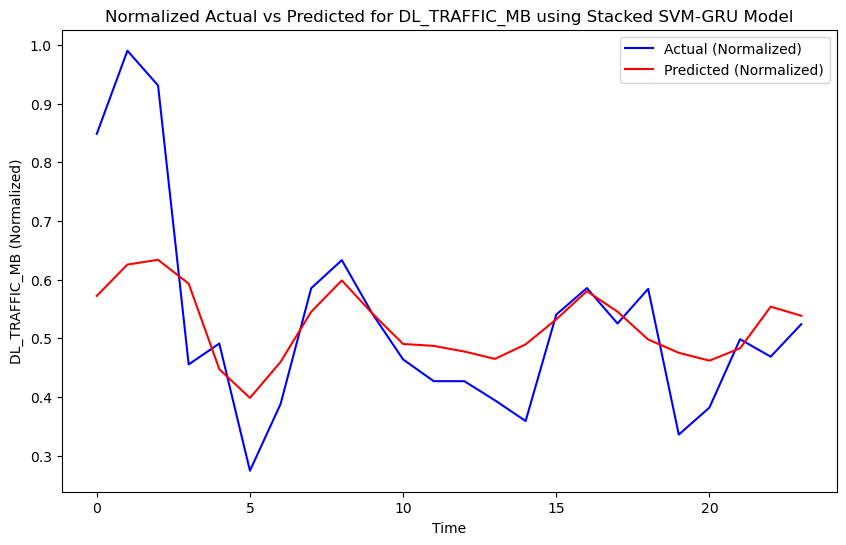

In [77]:

# Load your dataset (adjust the path to where your file is located)
data = pd.read_csv('../../data/Site2data.csv')

# Function to create dataset matrix for SVM
def create_dataset_svm(dataset, look_back=1):
    X, Y = [], []
    for i in range(len(dataset) - look_back):
        X.append(dataset[i:(i + look_back), 0])  # Flatten to 1D array for SVM
        Y.append(dataset[i + look_back, 0])
    return np.array(X), np.array(Y)

# Preparing data for 'Traffic'
feature = 'DL_TRAFFIC_MB'
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data[[feature]])

# Initialize the MaxAbsScaler
#scaler = MaxAbsScaler()

# Normalize the 'Traffic' data
#scaled_data = scaler.fit_transform(data[[feature]])

# Split the data into training and test sets (80% train, 20% test)
train_size = int(len(scaled_data) * 0.8)
train, test = scaled_data[:train_size], scaled_data[train_size:]

# Create dataset for SVM (look_back=3)
look_back = 3
X_train_svm, y_train_svm = create_dataset_svm(train, look_back=look_back)
X_test_svm, y_test_svm = create_dataset_svm(test, look_back=look_back)

# Train SVM model
svm_model = SVR(kernel='rbf', C=1, gamma='scale')
svm_model.fit(X_train_svm, y_train_svm)

# Predict with SVM model
train_predict_svm = svm_model.predict(X_train_svm)
test_predict_svm = svm_model.predict(X_test_svm)

# Prepare the data for GRU model
def create_dataset_gru(svm_predictions, original_data, look_back=1):
    X, Y = [], []
    for i in range(len(svm_predictions) - look_back):
        # Combine original time series data and SVM predictions as features
        feature_set = np.hstack((original_data[i:(i + look_back)], svm_predictions[i:(i + look_back)].reshape(-1, 1)))
        X.append(feature_set)
        Y.append(original_data[i + look_back, 0])
    return np.array(X), np.array(Y)

# Creating datasets for GRU
X_train_gru, y_train_gru = create_dataset_gru(train_predict_svm, train, look_back=look_back)
X_test_gru, y_test_gru = create_dataset_gru(test_predict_svm, test, look_back=look_back)

# Reshape input data to 3D (samples, timesteps, features) for GRU input
X_train_gru = np.reshape(X_train_gru, (X_train_gru.shape[0], X_train_gru.shape[1], 2))  # Two features: original and SVM
X_test_gru = np.reshape(X_test_gru, (X_test_gru.shape[0], X_test_gru.shape[1], 2))

# Define and train the GRU model
def build_gru_model(input_shape):
    model = Sequential()
    model.add(GRU(100, return_sequences=True, input_shape=input_shape))
    model.add(Dropout(0.2))
    model.add(GRU(50, return_sequences=False))
    model.add(Dense(1))  # Output layer for regression

    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

# Build and train GRU model
gru_model = build_gru_model((look_back, 2))
gru_model.fit(X_train_gru, y_train_gru, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

# Predict with the GRU model
train_predict_gru = gru_model.predict(X_train_gru)
test_predict_gru = gru_model.predict(X_test_gru)

# No need to invert the values; everything stays normalized

# Calculate normalized MSE
normalized_mse = mean_squared_error(y_test_gru, test_predict_gru)
print(f'Normalized MSE: {normalized_mse}')

# Plot the normalized actual vs predicted values
plt.figure(figsize=(10, 6))
plt.plot(y_test_gru, label='Actual (Normalized)', color='blue')
plt.plot(test_predict_gru, label='Predicted (Normalized)', color='red')
plt.title(f'Normalized Actual vs Predicted for {feature} using Stacked SVM-GRU Model')
plt.xlabel('Time')
plt.ylabel(f'{feature} (Normalized)')
plt.legend()
plt.show()

In [25]:
data

,Date,AVG_NO_USER,DL_TRAFFIC_MB,AVG_USR_THRPUT_DL
0,2023-04-03 00:00:00,0.00,0.00,0.000
1,2023-04-04 00:00:00,0.00,0.00,0.000
2,2023-04-05 00:00:00,0.00,0.00,0.000
3,2023-04-06 00:00:00,46.81,23158.42,4.620
4,2023-04-07 00:00:00,39.02,73899.97,5.160
...,...,...,...,...
141,2023-08-28 00:00:00,19.35,42203.47,24.735
142,2023-08-29 00:00:00,19.27,47197.89,23.725
143,2023-08-30 00:00:00,20.23,54606.66,24.175
144,2023-08-31 00:00:00,20.85,56421.17,25.070


In [26]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D,GRU, Dense, Flatten, Dropout

In [27]:
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator

Epoch 1/50
4/4 [==============================] - 14s 448ms/step - loss: 0.2819 - val_loss: 0.1653
Epoch 2/50
4/4 [==============================] - 0s 22ms/step - loss: 0.1474 - val_loss: 0.0597
Epoch 3/50
4/4 [==============================] - 0s 23ms/step - loss: 0.0631 - val_loss: 0.0166
Epoch 4/50
4/4 [==============================] - 0s 23ms/step - loss: 0.0426 - val_loss: 0.0370
Epoch 5/50
4/4 [==============================] - 0s 22ms/step - loss: 0.0569 - val_loss: 0.0325
Epoch 6/50
4/4 [==============================] - 0s 23ms/step - loss: 0.0431 - val_loss: 0.0170
Epoch 7/50
4/4 [==============================] - 0s 21ms/step - loss: 0.0363 - val_loss: 0.0181
Epoch 8/50
4/4 [==============================] - 0s 23ms/step - loss: 0.0363 - val_loss: 0.0194
Epoch 9/50
4/4 [==============================] - 0s 42ms/step - loss: 0.0355 - val_loss: 0.0163
Epoch 10/50
4/4 [==============================] - 0s 21ms/step - loss: 0.0333 - val_loss: 0.0156
Epoch 11/50
4/4 [==========

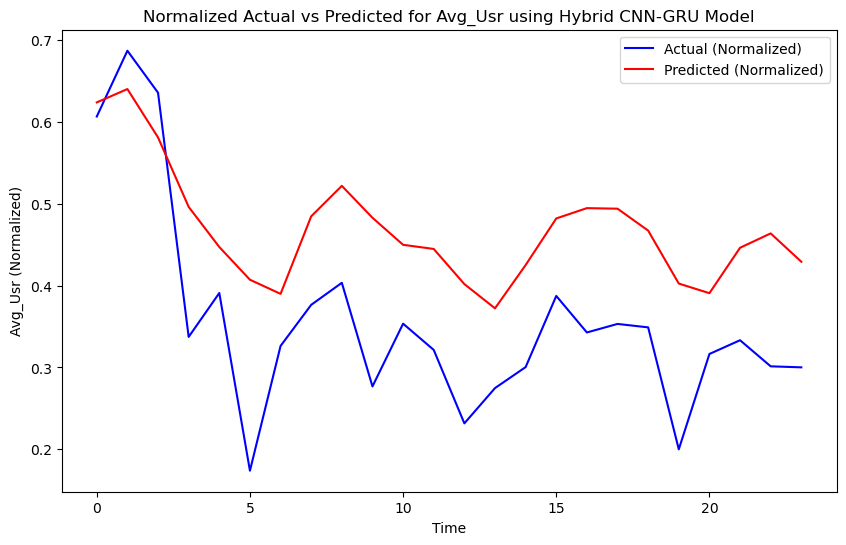

In [28]:
# Function to create dataset matrix for SVM
def create_dataset_svm(dataset, look_back=1):
    X, Y = [], []
    for i in range(len(dataset) - look_back):
        X.append(dataset[i:(i + look_back), 0])  # Flatten to 1D array for SVM
        Y.append(dataset[i + look_back, 0])
    return np.array(X), np.array(Y)

# Preparing data for 'AVG_NO_USER'
feature = 'AVG_NO_USER'
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data[[feature]])

# Split the data into training and test sets (80% train, 20% test)
train_size = int(len(scaled_data) * 0.8)
train, test = scaled_data[:train_size], scaled_data[train_size:]

# Create dataset for SVM (look_back=3)
look_back = 3
X_train_svm, y_train_svm = create_dataset_svm(train, look_back=look_back)
X_test_svm, y_test_svm = create_dataset_svm(test, look_back=look_back)

# Train SVM model
svm_model = SVR(kernel='rbf', C=1, gamma='scale')
svm_model.fit(X_train_svm, y_train_svm)

# Predict with SVM model
train_predict_svm = svm_model.predict(X_train_svm)
test_predict_svm = svm_model.predict(X_test_svm)

# Prepare the data for CNN-GRU model
def create_dataset_gru(svm_predictions, original_data, look_back=1):
    X, Y = [], []
    for i in range(len(svm_predictions) - look_back):
        # Combine original time series data and SVM predictions as features
        feature_set = np.hstack((original_data[i:(i + look_back)], svm_predictions[i:(i + look_back)].reshape(-1, 1)))
        X.append(feature_set)
        Y.append(original_data[i + look_back, 0])
    return np.array(X), np.array(Y)

# Creating datasets for CNN-GRU
X_train_gru, y_train_gru = create_dataset_gru(train_predict_svm, train, look_back=look_back)
X_test_gru, y_test_gru = create_dataset_gru(test_predict_svm, test, look_back=look_back)

# Reshape input data to 3D (samples, timesteps, features) for CNN and GRU input
X_train_gru = np.reshape(X_train_gru, (X_train_gru.shape[0], X_train_gru.shape[1], 2))  # Two features: original and SVM
X_test_gru = np.reshape(X_test_gru, (X_test_gru.shape[0], X_test_gru.shape[1], 2))

# Define the CNN-GRU model
def build_cnn_gru_model(input_shape):
    model = Sequential()
    
    # 1D CNN layers
    model.add(Conv1D(filters=64, kernel_size=2, activation='relu', input_shape=input_shape))
    model.add(MaxPooling1D(pool_size=2))
    model.add(Dropout(0.2))
    
    # GRU layers
    model.add(GRU(100, return_sequences=True))
    model.add(Dropout(0.2))
    model.add(GRU(50, return_sequences=False))
    
    # Dense output layer
    model.add(Dense(1))
    
    # Compile the model
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

# Build and train CNN-GRU model
cnn_gru_model = build_cnn_gru_model((look_back, 2))
cnn_gru_model.fit(X_train_gru, y_train_gru, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

# Predict with the CNN-GRU model
train_predict_gru = cnn_gru_model.predict(X_train_gru)
test_predict_gru = cnn_gru_model.predict(X_test_gru)

# Calculate normalized MSE
normalized_mse = mean_squared_error(y_test_gru, test_predict_gru)
print(f'Normalized MSE: {normalized_mse}')

# Plot the normalized actual vs predicted values
plt.figure(figsize=(10, 6))
plt.plot(y_test_gru, label='Actual (Normalized)', color='blue')
plt.plot(test_predict_gru, label='Predicted (Normalized)', color='red')
plt.title('Normalized Actual vs Predicted for Avg_Usr using Hybrid CNN-GRU Model')
plt.xlabel('Time')
plt.ylabel('Avg_Usr (Normalized)')
plt.legend()
plt.show()

Epoch 1/50
4/4 [==============================] - 13s 879ms/step - loss: 0.3181 - val_loss: 0.2834
Epoch 2/50
4/4 [==============================] - 0s 21ms/step - loss: 0.2808 - val_loss: 0.2422
Epoch 3/50
4/4 [==============================] - 0s 22ms/step - loss: 0.2405 - val_loss: 0.1938
Epoch 4/50
4/4 [==============================] - 0s 25ms/step - loss: 0.1910 - val_loss: 0.1367
Epoch 5/50
4/4 [==============================] - 0s 43ms/step - loss: 0.1398 - val_loss: 0.0749
Epoch 6/50
4/4 [==============================] - 0s 20ms/step - loss: 0.0807 - val_loss: 0.0250
Epoch 7/50
4/4 [==============================] - 0s 29ms/step - loss: 0.0406 - val_loss: 0.0187
Epoch 8/50
4/4 [==============================] - 0s 28ms/step - loss: 0.0436 - val_loss: 0.0352
Epoch 9/50
4/4 [==============================] - 0s 22ms/step - loss: 0.0520 - val_loss: 0.0245
Epoch 10/50
4/4 [==============================] - 0s 23ms/step - loss: 0.0370 - val_loss: 0.0149
Epoch 11/50
4/4 [==========

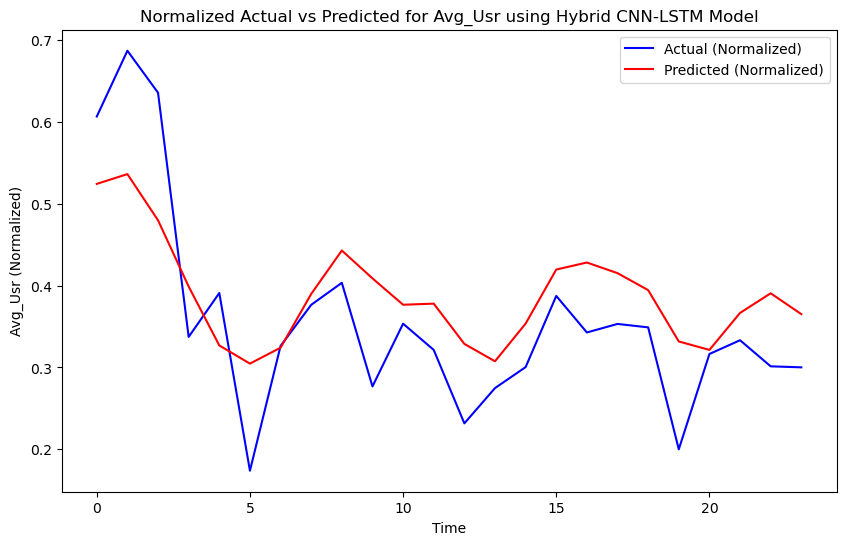

In [29]:
# Function to create dataset matrix for SVM
def create_dataset_svm(dataset, look_back=1):
    X, Y = [], []
    for i in range(len(dataset) - look_back):
        X.append(dataset[i:(i + look_back), 0])  # Flatten to 1D array for SVM
        Y.append(dataset[i + look_back, 0])
    return np.array(X), np.array(Y)

# Preparing data for 'AVG_NO_USER'
feature = 'AVG_NO_USER'
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data[[feature]])

# Split the data into training and test sets (80% train, 20% test)
train_size = int(len(scaled_data) * 0.8)
train, test = scaled_data[:train_size], scaled_data[train_size:]

# Create dataset for SVM (look_back=3)
look_back = 3
X_train_svm, y_train_svm = create_dataset_svm(train, look_back=look_back)
X_test_svm, y_test_svm = create_dataset_svm(test, look_back=look_back)

# Train SVM model
svm_model = SVR(kernel='rbf', C=1, gamma='scale')
svm_model.fit(X_train_svm, y_train_svm)

# Predict with SVM model
train_predict_svm = svm_model.predict(X_train_svm)
test_predict_svm = svm_model.predict(X_test_svm)

# Prepare the data for CNN-LSTM model
def create_dataset_lstm(svm_predictions, original_data, look_back=1):
    X, Y = [], []
    for i in range(len(svm_predictions) - look_back):
        # Combine original time series data and SVM predictions as features
        feature_set = np.hstack((original_data[i:(i + look_back)], svm_predictions[i:(i + look_back)].reshape(-1, 1)))
        X.append(feature_set)
        Y.append(original_data[i + look_back, 0])
    return np.array(X), np.array(Y)

# Creating datasets for CNN-LSTM
X_train_lstm, y_train_lstm = create_dataset_lstm(train_predict_svm, train, look_back=look_back)
X_test_lstm, y_test_lstm = create_dataset_lstm(test_predict_svm, test, look_back=look_back)

# Reshape input data to 3D (samples, timesteps, features) for CNN and LSTM input
X_train_lstm = np.reshape(X_train_lstm, (X_train_lstm.shape[0], X_train_lstm.shape[1], 2))  # Two features: original and SVM
X_test_lstm = np.reshape(X_test_lstm, (X_test_lstm.shape[0], X_test_lstm.shape[1], 2))

# Define the CNN-LSTM model
def build_cnn_lstm_model(input_shape):
    model = Sequential()
    
    # 1D CNN layers
    model.add(Conv1D(filters=64, kernel_size=2, activation='relu', input_shape=input_shape))
    model.add(MaxPooling1D(pool_size=2))
    model.add(Dropout(0.2))
    
    # LSTM layers
    model.add(LSTM(100, return_sequences=True))
    model.add(Dropout(0.2))
    model.add(LSTM(50, return_sequences=False))
    
    # Dense output layer
    model.add(Dense(1))
    
    # Compile the model
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

# Build and train CNN-LSTM model
cnn_lstm_model = build_cnn_lstm_model((look_back, 2))
cnn_lstm_model.fit(X_train_lstm, y_train_lstm, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

# Predict with the CNN-LSTM model
train_predict_lstm = cnn_lstm_model.predict(X_train_lstm)
test_predict_lstm = cnn_lstm_model.predict(X_test_lstm)

# Calculate normalized MSE
normalized_mse = mean_squared_error(y_test_lstm, test_predict_lstm)
print(f'Normalized MSE: {normalized_mse}')

# Plot the normalized actual vs predicted values
plt.figure(figsize=(10, 6))
plt.plot(y_test_lstm, label='Actual (Normalized)', color='blue')
plt.plot(test_predict_lstm, label='Predicted (Normalized)', color='red')
plt.title('Normalized Actual vs Predicted for Avg_Usr using Hybrid CNN-LSTM Model')
plt.xlabel('Time')
plt.ylabel('Avg_Usr (Normalized)')
plt.legend()
plt.show()

In [30]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, LSTM, Dense, Dropout, concatenate
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

Epoch 1/50
4/4 [==============================] - 7s 527ms/step - loss: 0.2746 - val_loss: 0.1425
Epoch 2/50
4/4 [==============================] - 0s 26ms/step - loss: 0.1222 - val_loss: 0.0403
Epoch 3/50
4/4 [==============================] - 0s 22ms/step - loss: 0.0451 - val_loss: 0.0185
Epoch 4/50
4/4 [==============================] - 0s 24ms/step - loss: 0.0389 - val_loss: 0.0347
Epoch 5/50
4/4 [==============================] - 0s 27ms/step - loss: 0.0534 - val_loss: 0.0298
Epoch 6/50
4/4 [==============================] - 0s 24ms/step - loss: 0.0402 - val_loss: 0.0196
Epoch 7/50
4/4 [==============================] - 0s 25ms/step - loss: 0.0333 - val_loss: 0.0164
Epoch 8/50
4/4 [==============================] - 0s 25ms/step - loss: 0.0297 - val_loss: 0.0162
Epoch 9/50
4/4 [==============================] - 0s 27ms/step - loss: 0.0296 - val_loss: 0.0158
Epoch 10/50
4/4 [==============================] - 0s 31ms/step - loss: 0.0299 - val_loss: 0.0150
Epoch 11/50
4/4 [===========

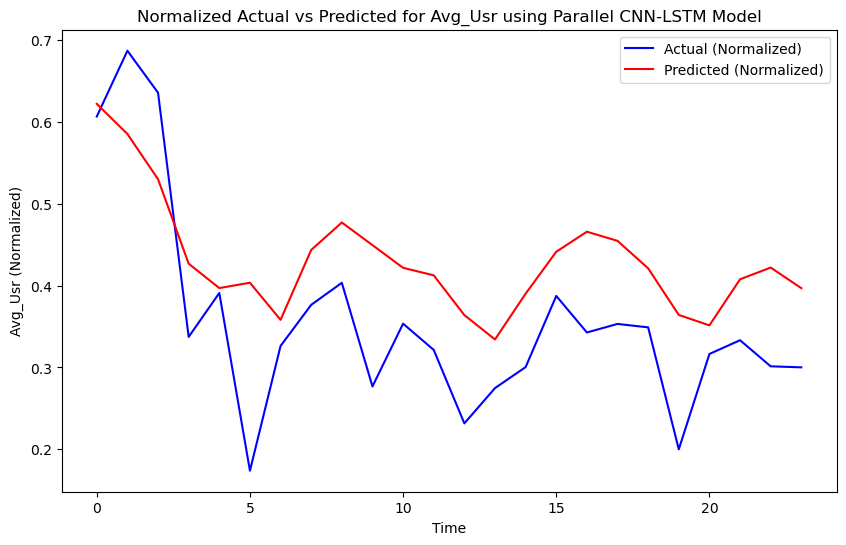

In [31]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, LSTM, Dense, Dropout, concatenate, Flatten
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

# Define the input shape
input_shape = (look_back, 2)  # look_back timesteps, 2 features (SVM and original)

# Define input layer
input_layer = Input(shape=input_shape)

# CNN Path
cnn = Conv1D(filters=64, kernel_size=2, activation='relu')(input_layer)
cnn = MaxPooling1D(pool_size=2)(cnn)
cnn = Dropout(0.2)(cnn)
cnn = Flatten()(cnn)  # Flatten CNN output to 2D

# LSTM Path
lstm = LSTM(100, return_sequences=False)(input_layer)
lstm = Dropout(0.2)(lstm)

# Merge the outputs of both paths
merged = concatenate([cnn, lstm])

# Fully connected layer
dense = Dense(50, activation='relu')(merged)
output = Dense(1)(dense)

# Build and compile the model
parallel_model = Model(inputs=input_layer, outputs=output)
parallel_model.compile(optimizer='adam', loss='mean_squared_error')

# Train the model
parallel_model.fit(X_train_gru, y_train_gru, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

# Predict with the parallel CNN-LSTM model
train_predict_parallel = parallel_model.predict(X_train_gru)
test_predict_parallel = parallel_model.predict(X_test_gru)

# Calculate normalized MSE
normalized_mse_parallel = mean_squared_error(y_test_gru, test_predict_parallel)
print(f'Normalized MSE: {normalized_mse_parallel}')

# Plot the normalized actual vs predicted values
plt.figure(figsize=(10, 6))
plt.plot(y_test_gru, label='Actual (Normalized)', color='blue')
plt.plot(test_predict_parallel, label='Predicted (Normalized)', color='red')
plt.title('Normalized Actual vs Predicted for Avg_Usr using Parallel CNN-LSTM Model')
plt.xlabel('Time')
plt.ylabel('Avg_Usr (Normalized)')
plt.legend()
plt.show()